## 🧩 Espacios proyectivos y matrices de proyección

Este ejercicio busca ilustrar cómo funcionan las **proyecciones en 3D** usando código. A través de un cubo que rota y se proyecta tanto de forma **ortográfica** como **en perspectiva**, se exploran conceptos como las **coordenadas homogéneas**, las **matrices de proyección** y la **visualización de profundidad**.
El objetivo es comprender cómo una escena tridimensional se convierte en una imagen bidimensional en la pantalla, tal como lo hacen las cámaras en gráficos 3D o videojuegos.

---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

 ### 1️⃣ Definición del cubo en coordenadas homogéneas

En esta primera parte se define un **cubo** a partir de sus **vértices** y **aristas**.
Cada vértice tiene cuatro componentes: `x`, `y`, `z` y un `1` adicional, lo que indica que se está trabajando en **coordenadas homogéneas**.
Este formato permite aplicar transformaciones lineales (como rotaciones o traslaciones) de forma más sencilla y uniforme.

---


In [ ]:
def crear_cubo():
    vertices = np.array([
        [-1, -1, -1, 1],
        [ 1, -1, -1, 1],
        [ 1,  1, -1, 1],
        [-1,  1, -1, 1],
        [-1, -1,  1, 1],
        [ 1, -1,  1, 1],
        [ 1,  1,  1, 1],
        [-1,  1,  1, 1]
    ])
    aristas = [
        (0,1),(1,2),(2,3),(3,0),
        (4,5),(5,6),(6,7),(7,4),
        (0,4),(1,5),(2,6),(3,7)
    ]
    return vertices, aristas


### 2️⃣ Matrices de proyección: ortográfica y perspectiva

Aquí se definen dos tipos de proyección:

* **Proyección ortográfica:** mantiene las líneas paralelas sin deformación, útil para planos técnicos o vistas isométricas.
* **Proyección en perspectiva:** imita la visión humana, donde los objetos lejanos se ven más pequeños y las líneas convergen hacia un punto de fuga.

Estas matrices son el núcleo de la proyección: transforman la posición 3D de los puntos en coordenadas que luego se pueden representar en 2D.

---

In [ ]:
def matriz_ortografica():
    return np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 0, 0],
        [0, 0, 0, 1]
    ])

def matriz_perspectiva(fov, aspect, near, far):
    f = 1 / np.tan(np.radians(fov) / 2)
    return np.array([
        [f/aspect, 0, 0, 0],
        [0, f, 0, 0],
        [0, 0, (far+near)/(near-far), (2*far*near)/(near-far)],
        [0, 0, -1, 0]
    ])


### 3️⃣ Transformaciones básicas: rotación y traslación

En esta parte se aplican transformaciones al cubo: primero se **rota** sobre el eje Y, y luego se **traslada** para situarlo frente a la cámara.
La rotación le da movimiento, mientras que la traslación evita que el cubo esté centrado en el mismo punto que la cámara.
Estas operaciones son esenciales para simular el movimiento o la vista desde diferentes ángulos en el espacio 3D.

---

In [ ]:
def rotar_y(angle):
    c, s = np.cos(angle), np.sin(angle)
    return np.array([
        [ c, 0, s, 0],
        [ 0, 1, 0, 0],
        [-s, 0, c, 0],
        [ 0, 0, 0, 1]
    ])
def transformar(vertices, matriz):
    """Aplica una matriz 4x4 a todos los vértices homogéneos"""
    return (matriz @ vertices.T).T

### 4️⃣ Proyección y normalización

Después de aplicar las transformaciones, los vértices del cubo deben **proyectarse** al plano 2D.
La función de proyección divide cada coordenada por su componente *w*, normalizando la posición del punto en pantalla.
Esto convierte las coordenadas homogéneas en posiciones visibles para dibujar.
Este paso refleja cómo la cámara “aplana” la escena tridimensional sobre la pantalla.

---

In [ ]:
def proyectar(vertices):
    w = vertices[:, 3]
    w[w == 0] = 1e-6
    return vertices[:, :3] / w[:, np.newaxis]


### 5️⃣ Animación del cubo proyectado

Finalmente, se genera una **animación** donde el cubo rota constantemente, mostrando la diferencia entre ambos tipos de proyección.
La vista ortográfica mantiene las proporciones sin deformar, mientras que la perspectiva da sensación de **profundidad y realismo**.
La animación alterna entre los dos modos, ilustrando cómo las matrices de proyección afectan la forma en que percibimos los objetos.

---


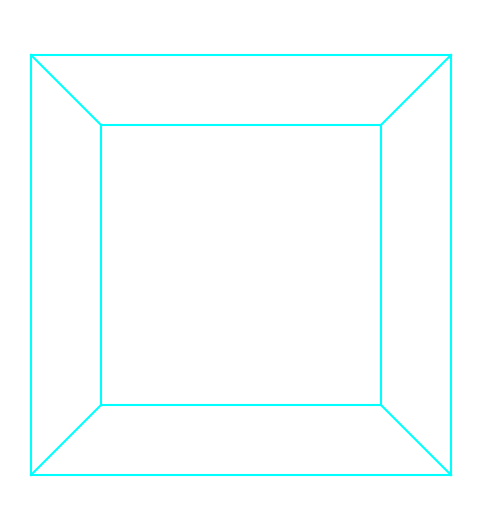

In [ ]:
# --- Configuración inicial ---
vertices, aristas = crear_cubo()
M_ortho = matriz_ortografica()
M_persp = matriz_perspectiva(fov=60, aspect=1, near=1, far=10)

modo_perspectiva = True  # alternar entre ortográfica / perspectiva

# --- Animación ---
fig, ax = plt.subplots(figsize=(6,6))
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_aspect('equal')
ax.axis('off')

def actualizar(frame):
    ax.clear()
    ax.axis('off')
    angulo = np.radians(frame)

    # rotar el cubo
    M_rot = rotar_y(angulo)
    cubo_rotado = transformar(vertices, M_rot)

    # trasladar el cubo hacia adelante (z negativo)
    T = np.array([
        [1,0,0,0],
        [0,1,0,0],
        [0,0,1,5],
        [0,0,0,1]
    ])
    cubo_cam = transformar(cubo_rotado, T)

    # aplicar proyección
    M_proj = M_persp if modo_perspectiva else M_ortho
    cubo_proj = transformar(cubo_cam, M_proj)
    cubo_2d = proyectar(cubo_proj)

    # dibujar aristas
    for (i,j) in aristas:
        x = [cubo_2d[i,0], cubo_2d[j,0]]
        y = [cubo_2d[i,1], cubo_2d[j,1]]
        ax.plot(x, y, 'cyan')

    # título según modo
    modo = "Perspectiva" if modo_perspectiva else "Ortográfica"
    ax.set_title(f"Proyección {modo}", color="white", fontsize=14)
    ax.set_facecolor("black")

ani = FuncAnimation(fig, actualizar, frames=np.arange(0, 360, 3), interval=80)
HTML(ani.to_jshtml())